
# Lab 3: PDE with FDM

In [153]:
#Librerias
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable

## **Exercise 1**: Finite-differences method (FDM) with tolerance **Jacobi method**.


Laplace's equation in the dominio $0\leq x \leq L$ and $0\leq y \leq L$ with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x)\to V_0=100$ V
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,L)=0$

1. Solve the Laplace's equation using finite differences for an specific tolerance ($10^{-6}<\text{tol}<10^{-1}$). Do a plot of the field $u(x,y)$ for $\text{tol}=10^{-3}$. Explain in your own words the strategy followed.
2. Compare with the **Fourier serie**. How many terms in the Fourier serie are necessary to get a $\text{tol}=10^{-4}$?

### <span style="color:green; font-size: 30px">Solución del Punto 1<span>

<span style="color:#7EED6D; font-size:20px">Codigo extraido de la sesion diferencias finitas<span>

In [ ]:
# Solución Numerica (Diferencias Finitas)
def Laplace2D_FDM(V_ini,Niter):
  'Int the V initial configutaration.\n Niter is the number of the iterations of the algorithm. Return V_out Laplace case.'
  Nmax = V_ini.shape[0]
  V = V_ini.copy()
  for iter in range(Niter):
    for i in range(1, Nmax-1):
      for j in range(1,Nmax-1):
        V[i,j] = 0.25*(V[i+1,j]+V[i-1,j]+V[i,j+1]+V[i,j-1])
  return V

In [24]:
def grid(V_ini,x,y):
  'to compute x,y,z'
  V = V_ini.copy()
  X, Y = np.meshgrid(x,y)
  Z = V[X,Y] 
  return X,Y,Z

<span style="color:#7EED6D; font-size:20px">Se explicara las modificaciones que se hicieron al codigo extraido de la sesion de diferencias finitas<span>

In [66]:
# Modificacion para una tolerancia
def FDM_tol(V_ini,tol=1e-3,max_iter=10000):
    N_max = V_ini.shape[0]
    V_new = V_ini.copy() # Se inicializa lo que va ser la malla nueva
    V_old = V_ini.copy() # Se inicializa lo que va ser la malla vieja
    for iter in range(max_iter): # Se comienza a evolucionar la malla
        error_max = 0 
        for i in range(1,N_max-1): # Se escribe N_max-1 por que es condición y ademas daria index error, 1 por que es la condicion del sistema no varia
            for j in range(1,N_max-1):
                V_new[i,j] = 0.25*(V_old[i+1,j]+V_old[i-1,j]+V_old[i,j+1]+V_old[i,j-1])
                error = abs(V_new[i,j] - V_old[i,j]) # Se calcula el error punto a punto
                error_max = max(error_max, error) # Se guarda el mayor error
        if error_max < tol: # Si la nueva malla converge para nuestra tolerancia ya no hay necesidad de seguir iterando 
            print(f"Numero de Iteracciones: {iter + 1} , para una toleracion de {tol}") # El +1 es por que iter empieza desde 0 
            return V_new 
        V_old = V_new.copy() # Ya se guarda la malla nueva que no cumplio la tolerancia, a ser la vieja malla
    print("Maxima de iteracciones realizadas, Max iter = 10000")
    return V_new

In [46]:
# Utiliznado Slicing (Mucho más rapida)
def FDM_tol_2(V_ini, tol=1e-3,max_iter=10000, error = 1): # error iicial, se debe cambiar si la tolerancia es mas alta que error
    V_new = V_ini.copy()
    n_iter = 0
    while error > tol and n_iter < max_iter:
        V_old = V_new.copy()
        V_new[1:-1, 1:-1] = 0.25 * (V_old[2:, 1:-1] + V_old[:-2, 1:-1] + V_old[1:-1, 2:] + V_old[1:-1, :-2]) # Hace (i,j) en una sola linea de codigo
        error = np.max(np.abs(V_new - V_old)) # Se encuentra el maximo error 
        n_iter += 1 
    print(f"Numero de Iteracciones: {n_iter} , para una toleracion de {tol}")
    return V_new

In [ ]:
Nmax = 100
V_ini = np.zeros((Nmax, Nmax), float) 
for k in range(Nmax):
  V_ini[k,0] = 100 # Condicción de Frontera V_o = 100V
x = np.arange(0, Nmax , 1) # V_ini tiene es una matriz 100x100 entonces Nmax-1 hara que no se muestre el indice 99 
y = x

In [71]:
V = FDM_tol(V_ini)

Numero de Iteracciones: 5991 , para una toleracion de 0.001


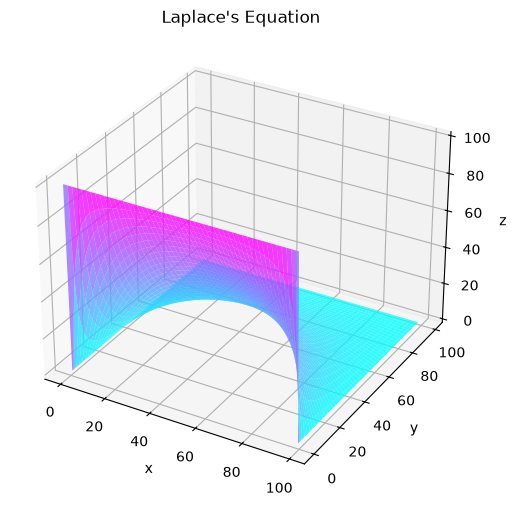

In [72]:
X,Y,Z = grid(V,x,y)
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='cool', alpha=0.8)
ax.set_title("Laplace's Equation")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

In [52]:
V = FDM_tol_2(V_ini)

Numero de Iteracciones: 5991 , para una toleracion de 0.001


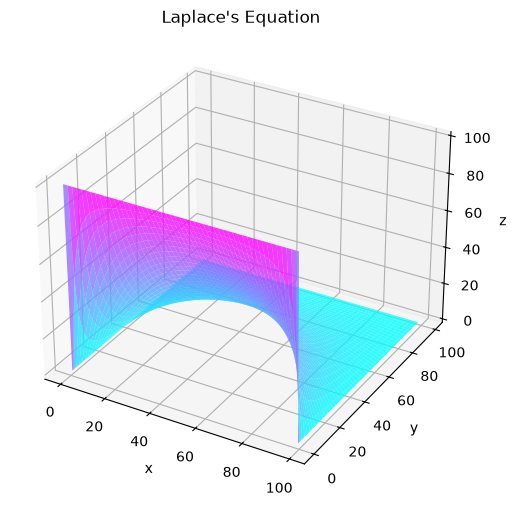

In [53]:
X,Y,Z = grid(V,x,y)
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='cool', alpha=0.8)
ax.set_title("Laplace's Equation")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

In [48]:
V = FDM_tol_2(V_ini, tol= 2, error= 10)

Numero de Iteracciones: 12 , para una toleracion de 2


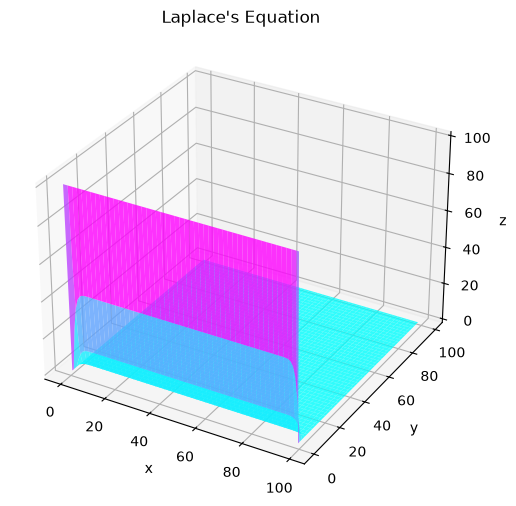

In [49]:
X,Y,Z = grid(V,x,y)
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='cool', alpha=0.8)
ax.set_title("Laplace's Equation")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

### <span style="color:green; font-size: 30px">Solución del Punto 2<span>

<span style="color:#7EED6D; font-size:20px">Codigo extraido de la sesion teoria de las PDE</span>

In [ ]:
# Solución Analitca
def Analitica(x,y,n=1,L=1):
  'function to compute the n-esimo term of the Fouriers serie'
  v0 = 100 #Voltage
  return (4*v0/(n*np.pi))*np.sin(n*np.pi*x/L)*np.sinh(n*np.pi*(L-y)/L)/np.sinh(n*np.pi)

In [105]:
#Making the grid to do the plot
L = 1 # Longitude
coordx = np.linspace(0,L,100) # 100 puntos
coordy = coordx
x , y = np.meshgrid(coordx, coordy, indexing= 'ij')

<span style="color:#7EED6D; font-size:20px">Se explicara las modificaciones que se hicieron al codigo extraido de la sesion teoria de las PDE</span>

In [137]:
# Solución Analitica con tolerancia como criterio
def  Analitica_tol(x,y,tol=1e-3,L=1):
    n = 1 # primer termino
    V_n = np.zeros((len(x), len(y))) # Se inicializa la malla que se va a ir sumando el n termino siguiente
    while True:
        n_t = Analitica(x,y,n=n,L=L) # Se calcula el n termino
        error = np.max(np.abs(n_t)) # Se calcula el error o en este caso el cambio que aporta el n termino
        V_n += n_t # Se suma a la solución
        if error < tol:
            print(f"Numero de terminos que fue necesario fue: {(n+1)/2}, para una tolerancia de: {tol}")
            break
        n +=2 # Terminos impares 
    return V_n

In [148]:
V = Analitica_tol(x,y)

Numero de terminos que fue necesario fue: 50.0, para una tolerancia de: 0.001


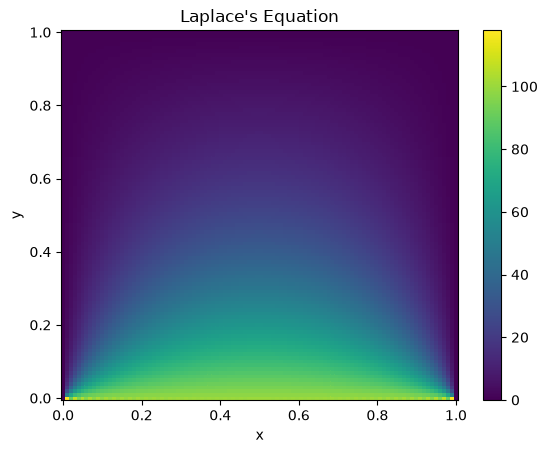

In [149]:
plt.pcolor(x, y, V)
plt.colorbar()
plt.xlabel('x')
plt.ylabel('y')
plt.title("Laplace's Equation")
plt.show()

In [140]:
V = Analitica_tol(x,y,tol=1e-4)

Numero de terminos que fue necesario fue: 50.0, para una tolerancia de: 0.0001


In [146]:
V = Analitica_tol(x,y,tol=2)

Numero de terminos que fue necesario fue: 33.0, para una tolerancia de: 2


$\color{#7EED6D}{\text{\large Lo que pasa es que del término } 97 \text{ a } 99 \text{ pasa de un error de } 1.31 \text{ aproximadamente a } 8.57 \times 10^{-14}\text{, por eso la cantidad de términos para una tolerancia de } 10^{-3} \text{ o } 10^{-4} \text{ es la misma.}}$

## **Exercise 2**: FDM for oppen boundaries (bonus!)

1. Solve **analytically** the Laplace's equation for $u(x,y)$ in the dominio $0\leq x \leq L$ and $0\leq y < \infty $, with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x) = u_0\sin(2\pi x/L)e^{-2\pi y/L}$
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,\infty)=0$,

Explain in your own words the strategy followed and write the analytical result.


1. Solve **numerically** the Laplace's equation, set the lenght $L=N\Delta = 100$ and $\Delta=1$ and $u_0=100$.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_4.png" width="200" height="300" />

## Electric filed and potential in a parallel-plate capacitor

#### **Exercise 3** 

To find the potential generated by a capacitor  of two rectangular plates of width $d$ is challenging (see figure). In general, we can do some approximation based in infinite plates to get an intuition of the solution. In this approximation we have:


\begin{equation}
|\vec{E}| \approx \dfrac{\sigma}{2\epsilon_0}, \text{inside}\,,
\end{equation}

\begin{equation}
|\vec{E}| \approx 0, \text{  outside}\,.
\end{equation}


However, we know that the potential $\phi$ and the electric field $\vec{E}$ fulfill the Laplace's equation $\nabla^2\phi = 0$ in the region around the plates (where $\rho=0$).

1. Use finite differences to solve the Laplace's equation in the neigborhood of this capacitor. Use the imshow or the contour function to plot the potential.

2. Compute numerically the electric field (use finite difference method).

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_capacitor.png" alt="drawing" width="600"/>

### <span style="color:green; font-size: 30px">Solución del Punto 1<span>

<span style="color:#7EED6D; font-size:20px">Condiciones Iniciales</span>

In [ ]:
Nmax = 100 
potencial_ini = np.zeros((Nmax, Nmax), float) 
for k in range(Nmax):
  potencial_ini[40:60,40] = 10 # Placa Positiva
  potencial_ini[40:60,-40] = -10 # Placa Negativa a una distancia de 20 puntos

<span style="color:#7EED6D; font-size:20px">Funcion para Diferencias Finitas del Problema</span>

In [ ]:
def Potencial_FDM(P_ini, tol=1e-3,max_iter=10000, error = 1): # error iicial, se debe cambiar si la tolerancia es mas alta que error
    P_new = P_ini.copy()
    placas = P_ini !=0 # Se guarda las posiciones de las placas en boleanos
    n_iter = 0
    while error > tol and n_iter < max_iter:
        P_old = P_new.copy()
        P_new[1:-1, 1:-1] = 0.25 * (P_old[2:, 1:-1] + P_old[:-2, 1:-1] + P_old[1:-1, 2:] + P_old[1:-1, :-2])
        P_new[placas] = P_ini[placas] # Las placas no cambian entonces se restaura sus valores
        error = np.max(np.abs(P_new - P_old)) 
        n_iter += 1 
    print(f"Numero de Iteracciones: {n_iter} , para una toleracion de {tol}")
    return P_new

In [129]:
P = Potencial_FDM(potencial_ini)

Numero de Iteracciones: 1091 , para una toleracion de 0.001


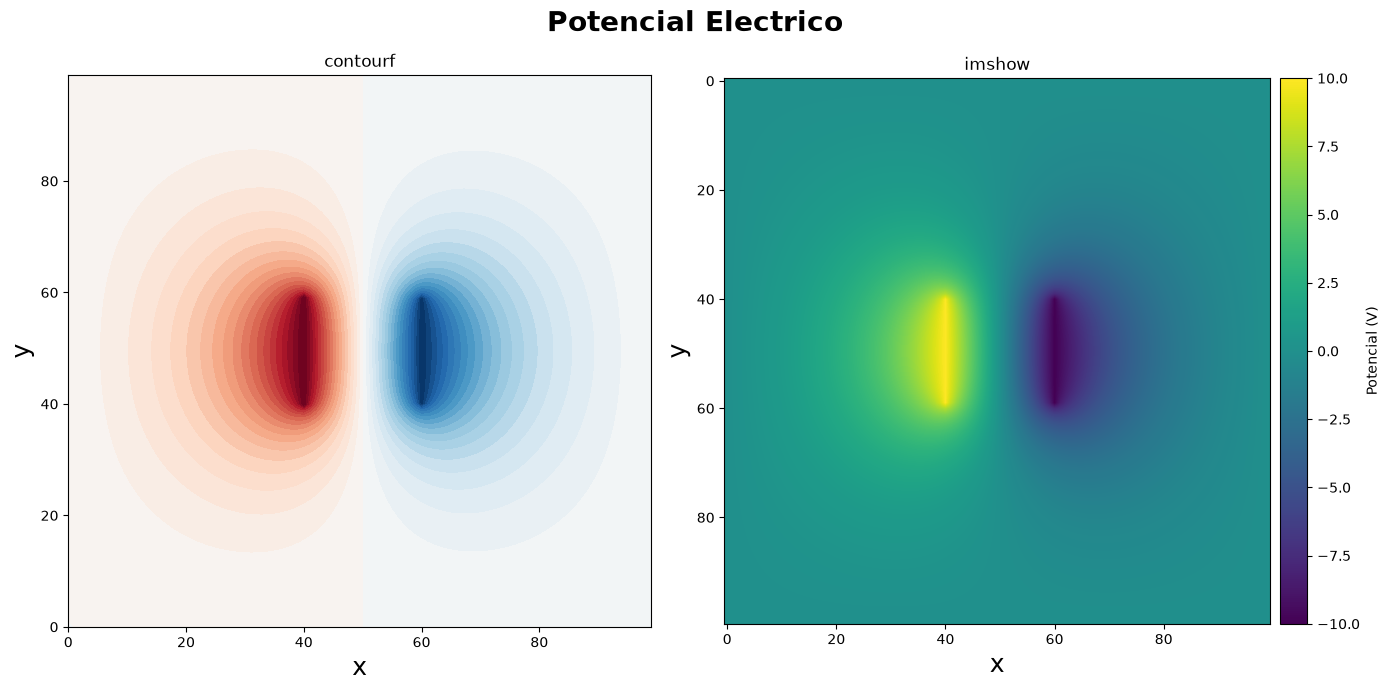

In [154]:
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,7))

plt.suptitle(
    "Potencial Electrico",
    fontsize="20",
    fontweight=700,
)

ax[0].contourf(P,levels = 40, cmap='RdBu_r')
ax[0].set_title("contourf")
ax[0].set_xlabel("x",size=18)
ax[0].set_ylabel("y",size=18)

im = ax[1].imshow(P.copy(), interpolation="bilinear") # cmap="hot"
ax[1].set_title("imshow")
ax[1].set_xlabel("x",size=18)
ax[1].set_ylabel("y",size=18)

divider = make_axes_locatable(ax[1]) # Crea el espacio donde va ir la barra de color, independiente del espacio de la figura relacionada
cax = divider.append_axes("right", size="5%", pad=0.1)
fig.colorbar(im, cax=cax, label="Potencial (V)")


plt.tight_layout()
plt.show()



### <span style="color:green; font-size: 30px">Solución del Punto 2<span>

Once you have a solution for $U(x, y)$ on a grid, it is simple to use the central-difference approximation for the derivative to determine the field, for example:


$$ E_{x} \approx  \dfrac{U(x+\Delta,y) -U(x-\Delta,y)}{2\Delta_x} = \dfrac{U_{i+1,j}-U_{i-1,j}}{2\Delta_x} $$
$$ E_y \approx \dfrac{U(x, y+\Delta) -U(x,y-\Delta)}{2\Delta_y} = \dfrac{U_{i,j+1}-U_{i,j-1}}{2\Delta_y}$$

<span style="color:#7EED6D; font-size:20px"> Codigo extraido de la sesion metodo de diferencias finitas</span>

In [158]:
E = -np.stack([
    (P[2:, 1:-1] - P[0:-2, 1:-1]) / 2, # Ex
    (P[1:-1, 2:] - P[1:-1, 0:-2]) / 2, # Ey
], axis=-1)

Ex = E[..., 0]
Ey = E[..., 1]

<span style="color:#7EED6D; font-size:20px">Establezco el grid con unidades fisicas</span>

In [ ]:
# Numero de Puntos
Nx = 100 
Ny = 100 
# Distancia entre puntos en cm
d = 20 
l = 20 
# Conversion a metros
dx = d/100 
dy = l/100
# Unidades reales (Nx-2 que es el tamaño de Ex y Ey) para la grafica de E
x_real = np.arange(1, Nx-1) * dx 
y_real = np.arange(1, Nx-1) * dy
X, Y = np.meshgrid(x_real, y_real, indexing='ij')
# Coordenadas completas para la imagen de fondo (100 puntos)
x_max = Nx * dx
y_max = Ny * dy

In [204]:
magnitude = np.sqrt(Ex**2 + Ey**2)

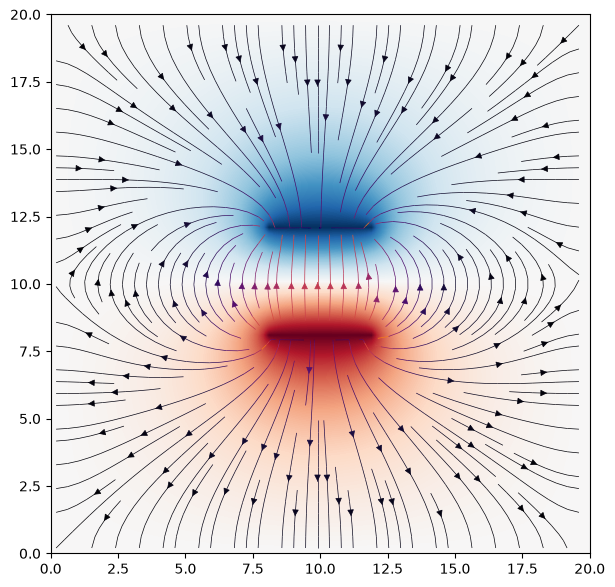

In [207]:
fig, ax = plt.subplots(figsize=(15, 7))

ax.imshow(P.T, origin='lower', cmap='RdBu_r', extent=[0, x_max, 0, y_max],interpolation="bilinear") # Se extiende a 100 puntos que es el tamaño de P
ax.streamplot(X.T, Y.T, Ex.T, Ey.T,
                color = magnitude.T, cmap = 'inferno',
                density=1.5, linewidth=0.5)

ax.set_aspect('equal')
plt.show()